In [ ]:
%pip install torch torchvision matplotlib --break-system-packages

Using device: cpu


100.0%
100.0%
100.0%
100.0%


Training AE and VAE for 3 quick epochs...
Epoch 1/3 Complete.
Epoch 2/3 Complete.
Epoch 3/3 Complete.


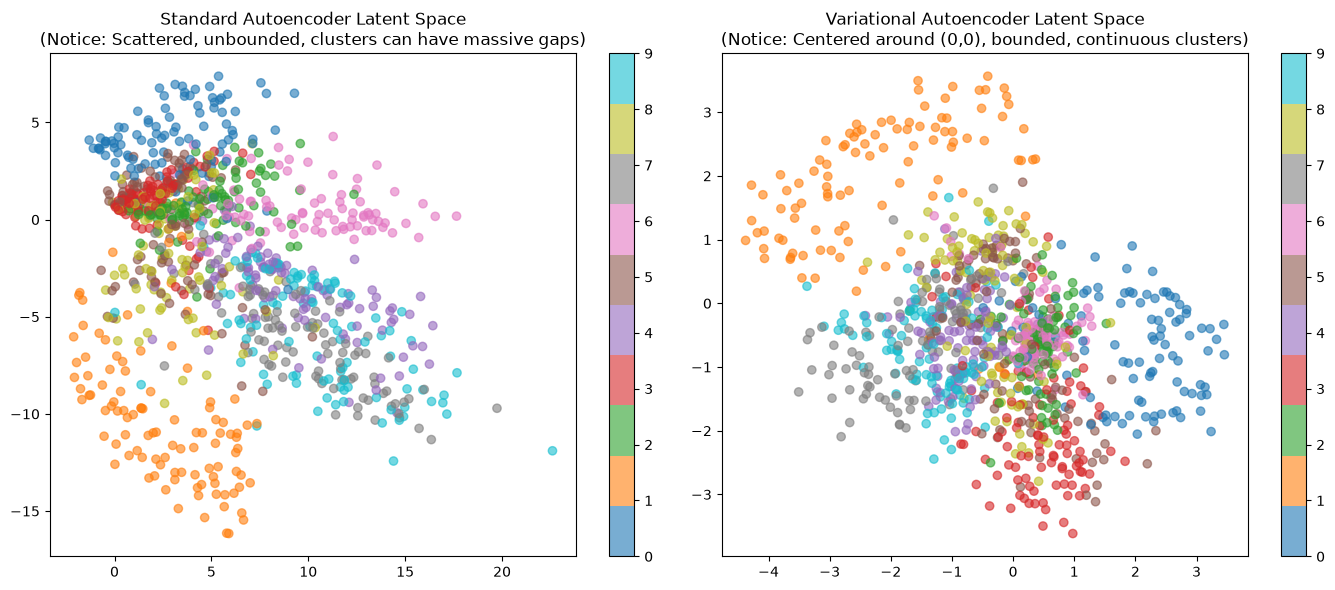

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. SETUP & DATA PREPARATION
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# ---------------------------------------------------------
# 2. STANDARD AUTOENCODER (AE)
# ---------------------------------------------------------
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder: Compresses 784 -> 128 -> 2 (Deterministic Bottleneck)
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # Fixed 2D point
        )
        # Decoder: Reconstructs 2 -> 128 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent

# ---------------------------------------------------------
# 3. VARIATIONAL AUTOENCODER (VAE)
# ---------------------------------------------------------
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Shared Encoder Backbone
        self.encoder_backbone = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU()
        )
        # Probabilistic Bottleneck (Outputs Mean and Log-Variance)
        self.fc_mu = nn.Linear(128, 2)
        self.fc_logvar = nn.Linear(128, 2)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        # Reparameterization trick: samples from N(mu, var)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder_backbone(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(z)
        return reconstruction, mu, logvar

# VAE Loss = Reconstruction Loss + KL Divergence
def vae_loss_fn(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # KL Divergence formula forces latent space to be Normal Distribution N(0, 1)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

# ---------------------------------------------------------
# 4. TRAINING SIMULATION (Shortened for Quick Demo)
# ---------------------------------------------------------
ae = Autoencoder().to(device)
vae = VAE().to(device)

ae_optimizer = optim.Adam(ae.parameters(), lr=0.001)
vae_optimizer = optim.Adam(vae.parameters(), lr=0.001)

print("Training AE and VAE for 3 quick epochs...")
epochs = 3

for epoch in range(epochs):
    ae.train()
    vae.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        # --- Train AE ---
        ae_optimizer.zero_grad()
        recon_ae, _ = ae(data)
        ae_loss = nn.functional.binary_cross_entropy(recon_ae, data.view(-1, 784), reduction='sum')
        ae_loss.backward()
        ae_optimizer.step()
        
        # --- Train VAE ---
        vae_optimizer.zero_grad()
        recon_vae, mu, logvar = vae(data)
        vae_loss = vae_loss_fn(recon_vae, data, mu, logvar)
        vae_loss.backward()
        vae_optimizer.step()
    print(f"Epoch {epoch+1}/{epochs} Complete.")

# ---------------------------------------------------------
# 5. VISUALIZING THE DIFFERENCE IN LATENT SPACE
# ---------------------------------------------------------
ae.eval()
vae.eval()

# Grab a single batch to plot
test_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
data, labels = next(iter(test_loader))
data = data.to(device)

with torch.no_grad():
    _, ae_latent = ae(data)
    _, vae_mu, _ = vae(data) # We use Mu as the representation for VAE
    
ae_latent = ae_latent.cpu().numpy()
vae_mu = vae_mu.cpu().numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Autoencoder Latent Space
scatter1 = axes[0].scatter(ae_latent[:, 0], ae_latent[:, 1], c=labels, cmap='tab10', alpha=0.6)
axes[0].set_title("Standard Autoencoder Latent Space\n(Notice: Scattered, unbounded, clusters can have massive gaps)")
fig.colorbar(scatter1, ax=axes[0])

# Plot VAE Latent Space
scatter2 = axes[1].scatter(vae_mu[:, 0], vae_mu[:, 1], c=labels, cmap='tab10', alpha=0.6)
axes[1].set_title("Variational Autoencoder Latent Space\n(Notice: Centered around (0,0), bounded, continuous clusters)")
fig.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()